In [6]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import os
import cv2
from torch import  randint
from pathlib import Path
from glob import glob
import numpy as np
from torch.utils.data import random_split, DataLoader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
id2int = {'Parasitized': 0, 'Uninfected': 1}

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ColorJitter(brightness=(0.95,1.05), contrast=(0.95,1.05), saturation=(0.95,1.05), hue=0.05),
    transforms.RandomAffine(degrees=5, translate=(0.01,0.1), scale=(0.9,1.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class Malaria(Dataset):
    def __init__(self, files, tfms=None):
        self.files = files
        self.tfms = tfms
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        path = self.files[idx]
        cls = os.path.basename(Path(path).parent)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        return img, cls
    
    def choose(self):
        return self[randint(len(self.files))]
        
    def collate_fn(self, batch):
        _imgs, labels = list(zip(*batch))
        imgs = [self.tfms(img).unsqueeze(0)  for img in _imgs]
        labels = [torch.tensor([id2int[i] for i in labels])]
        imgs, labels = [torch.cat(i).to(device) for i in (imgs, labels)]
        return imgs, labels, _imgs

def conv_block(input_channels, out_channels, pool=True):
    return nn.Sequential(
        nn.Dropout(0.1),
        nn.Conv2d(input_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2)
    )

class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.model = nn.Sequential(
            conv_block(3, 64, pool=True),
            conv_block(64, 64, pool=True),
            conv_block(64, 128, pool=True),
            conv_block(128, 256, pool=True),
            conv_block(256, 512, pool=True),
            conv_block(512, 64, pool=True),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, len(id2int))
        )
    def forward(self, x):
        return self.model(x)


def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

def train(model, train_loader, criterion=nn.CrossEntropyLoss, optimizer=Adam, epochs=5):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    for epoch in range(epochs):
        for i, (inputs, labels, _) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = accuracy(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            running_acc += acc.item()
            
            if (i+1) % 10 == 0:
                print(f"Epoch [{epoch+1}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/10:.4f}, Acc: {running_acc/10:.4f}")
                running_loss = 0.0
                running_acc = 0.0
            
@torch.no_grad()
def evaluate(model, val_loader, criterion=nn.CrossEntropyLoss):
    with torch.no_grad():
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        for i, (inputs, labels, _) in enumerate(val_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = accuracy(outputs, labels)
            
            val_loss += loss.item()
            val_acc += acc.item()
        val_loss /= len(val_loader)
        val_acc /= len(val_loader)
        print(f"Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}")
    
    
if __name__ == "__main__":
    all_files = glob('cell_images/*/*.png')
    # print(len(all_files))
    np.random.shuffle(all_files)

    train_size = int(0.8*len(all_files))
    test_size = len(all_files) - train_size


    train_files, test_files = random_split(all_files, [train_size, test_size])
    train_data = Malaria(train_files, tfms=train_tfms)
    test_data = Malaria(test_files, tfms=val_tfms)
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=train_data.collate_fn)
    val_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=test_data.collate_fn)
    
    model = MyNet().to(device)
    optimizer = Adam(model.parameters(), lr=0.001)
    
    train(model, train_loader, criterion=nn.CrossEntropyLoss(), optimizer=optimizer, epochs=5)
    evaluate(model, val_loader, criterion=nn.CrossEntropyLoss())
    torch.save(model.state_dict(), 'malaria_model.pth')
    print("Model saved as malaria_model.pth")
    

Epoch [1], Step [10/689], Loss: 0.7621, Acc: 0.5188
Epoch [1], Step [20/689], Loss: 0.6935, Acc: 0.5687
Epoch [1], Step [30/689], Loss: 0.6235, Acc: 0.6844
Epoch [1], Step [40/689], Loss: 0.5728, Acc: 0.7312
Epoch [1], Step [50/689], Loss: 0.4350, Acc: 0.8375
Epoch [1], Step [60/689], Loss: 0.3365, Acc: 0.8688
Epoch [1], Step [70/689], Loss: 0.2306, Acc: 0.9250
Epoch [1], Step [80/689], Loss: 0.3223, Acc: 0.8906
Epoch [1], Step [90/689], Loss: 0.2124, Acc: 0.9375
Epoch [1], Step [100/689], Loss: 0.2551, Acc: 0.9125
Epoch [1], Step [110/689], Loss: 0.3017, Acc: 0.8969
Epoch [1], Step [120/689], Loss: 0.2150, Acc: 0.9250
Epoch [1], Step [130/689], Loss: 0.1777, Acc: 0.9437
Epoch [1], Step [140/689], Loss: 0.2600, Acc: 0.9219
Epoch [1], Step [150/689], Loss: 0.1999, Acc: 0.9313
Epoch [1], Step [160/689], Loss: 0.1911, Acc: 0.9406
Epoch [1], Step [170/689], Loss: 0.2021, Acc: 0.9437
Epoch [1], Step [180/689], Loss: 0.1367, Acc: 0.9531
Epoch [1], Step [190/689], Loss: 0.1662, Acc: 0.9406
Ep

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26348\3484064996.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("malaria_model.pt

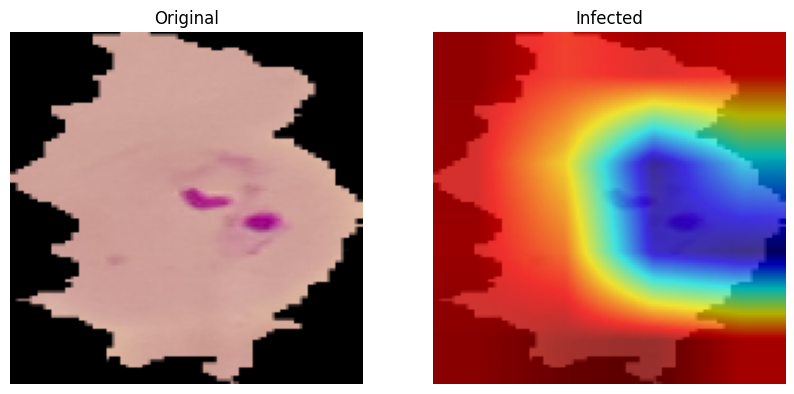

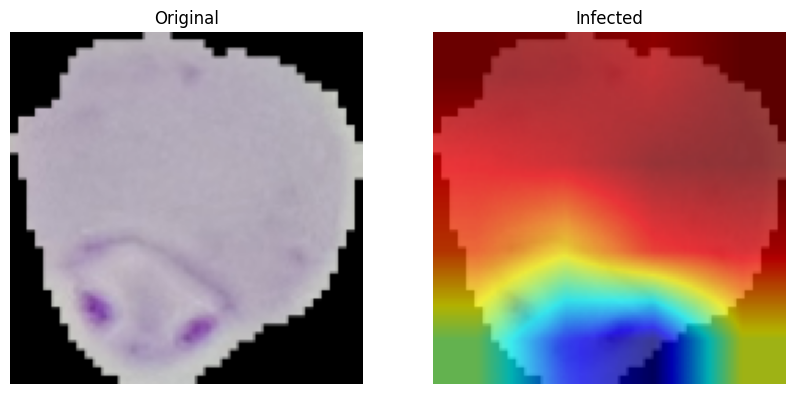

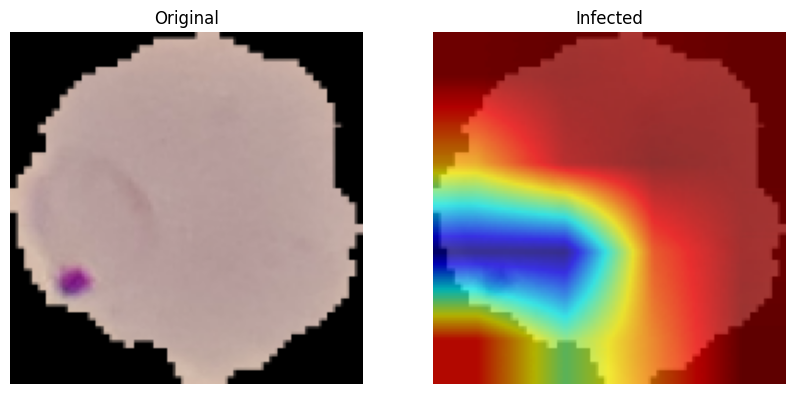

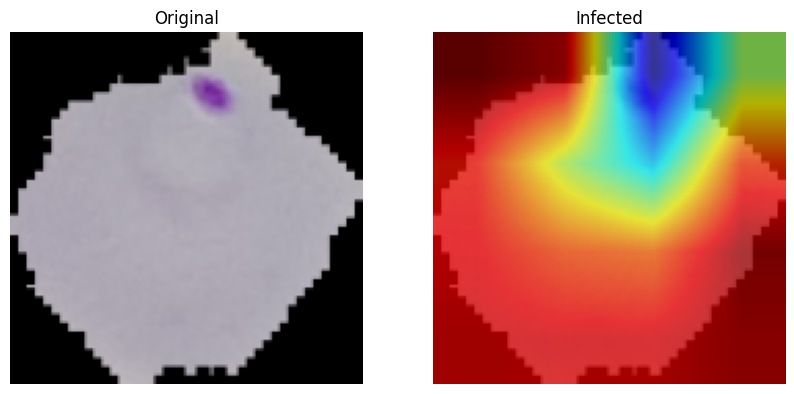

In [11]:
import torch.nn as nn
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import os
import cv2
from torch import  randint
from pathlib import Path
from glob import glob
import numpy as np
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
id2int = {'Parasitized': 0, 'Uninfected': 1}

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ColorJitter(brightness=(0.95,1.05), contrast=(0.95,1.05), saturation=(0.95,1.05), hue=0.05),
    transforms.RandomAffine(degrees=5, translate=(0.01,0.1), scale=(0.9,1.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class Malaria(Dataset):
    def __init__(self, files, tfms=None):
        self.files = files
        self.tfms = tfms
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        path = self.files[idx]
        cls = os.path.basename(Path(path).parent)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        return img, cls
    
    def choose(self):
        return self[randint(len(self.files))]
        
    def collate_fn(self, batch):
        _imgs, labels = list(zip(*batch))
        imgs = [self.tfms(img).unsqueeze(0)  for img in _imgs]
        labels = [torch.tensor([id2int[i] for i in labels])]
        imgs, labels = [torch.cat(i).to(device) for i in (imgs, labels)]
        return imgs, labels, _imgs

def conv_block(input_channels, out_channels, pool=True):
    return nn.Sequential(
        nn.Dropout(0.1),
        nn.Conv2d(input_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2)
    )
    
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.model = nn.Sequential(
            conv_block(3, 64, pool=True),
            conv_block(64, 64, pool=True),
            conv_block(64, 128, pool=True),
            conv_block(128, 256, pool=True),
            conv_block(256, 512, pool=True),
            conv_block(512, 64, pool=True),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, len(id2int))
        )
    def forward(self, x):
        return self.model(x)
    



val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(128),
    
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def img2gradCAM(x):
    model.eval()
    logits = model(x)
    heatmaps = []
    activation = img2fmap(x)
    # print(activation.shape)
    pred = logits.max(-1)[-1]
    model.zero_grad()
    logits[0,pred].backward()
    pool_grads = model.model[-6][1].weight.grad.data.mean((1,2,3))
    for i in range(activation.shape[1]):
        activation[:,i,:,:] *= pool_grads[i]
    heatmap = torch.mean(activation, dim=1)[0].cpu().detach()
    return heatmap, "Uninfected" if pred.item() else "Infected"


def upsampleHeatmap(map, size, image):
    m, M = map.min(), map.max()
    map = 255*(map-m)/(M-m)
    map = np.uint8(map)
    map = cv2.resize(map, (size, size))
    map = cv2.applyColorMap(map, cv2.COLORMAP_JET)
    map = np.uint8(map)
    map = np.uint8(map*0.7 + image*0.3)
    return map


all_files = glob("cell_images/*/*.png")
np.random.shuffle(all_files)

train_size = int(0.8*len(all_files))
test_size = len(all_files) - train_size
img2fmap = nn.Sequential(*(list(model.model[:5].children())) + list(model.model[5][:2].children()))

train_files, test_files = random_split(all_files, [train_size, test_size])
train_data = Malaria(train_files, tfms=train_tfms)
test_data = Malaria(test_files, tfms=val_tfms)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=train_data.collate_fn)
val_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=test_data.collate_fn)

model = MyNet().to(device)
model.load_state_dict(torch.load("malaria_model.pth"))
 
N = 10
SZ = 128
_val_dataloader = DataLoader(test_data, batch_size=10, shuffle=False, collate_fn=test_data.collate_fn)
x, y, z = next(iter(_val_dataloader))
for i in range(N):
    image = cv2.resize(z[i], (SZ, SZ))
    heatmap, pred = img2gradCAM(x[i:i+1])
    if(pred == "Uninfected"):
        continue
    heatmap = upsampleHeatmap(heatmap, SZ, image)
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Original")
    plt.subplot(1,2,2)
    plt.imshow(heatmap)
    plt.axis("off")
    plt.title(pred)
    plt.show()




